# Benchmark analysis

Load the `N=50` benchmark, compute ranking metrics at 50 and 300, and summarize performance by disease and across diseases. Rankings are restricted to the top 500 candidates for faster exploratory analysis.

In [67]:
import pickle
import sys
from pathlib import Path
from tqdm import tqdm

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if not (project_root / "bioGraph").is_dir():
    raise FileNotFoundError("Start Jupyter from the repository root or notebooks directory.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

class NumPyCompatibleUnpickler(pickle.Unpickler):
    """Load NumPy 2.x pickles with kernels that still use NumPy 1.x."""

    def find_class(self, module, name):
        if module == "numpy._core" or module.startswith("numpy._core."):
            module = module.replace("numpy._core", "numpy.core", 1)
        return super().find_class(module, name)


results_path = project_root / "outputs" / "results" / "results_N50.pkl"
with results_path.open("rb") as handle:
    benchmark_results = NumPyCompatibleUnpickler(handle).load()

print(f"Loaded {results_path}")
print(f"Runs: {len(benchmark_results['runs']):,}")

Loaded /Users/valentin/Documents/1_Promotion/Biological Networks/bioGraph/outputs/results/results_N50.pkl
Runs: 3,500


In [68]:
import numpy as np
import pandas as pd
from IPython.display import display

from bioGraph import sim
from bioGraph.evaluation.metrics import compute_ranking_metrics

sim.validate_benchmark_results(benchmark_results)

runs = benchmark_results["runs"]
nodelist = np.asarray(benchmark_results["nodelist"])
disease_set = benchmark_results["config"]["disease_set"]
method_set = benchmark_results["config"]["method_set"]
metric_cutoffs = (25, 100)
comparison_cutoffs = (25, 300)
pathway_metric = "recall"  # Use "average_precision" for AP.
pathway_metric_cutoff = 100  # Suggested: Recall@100 or AP@25.
color_threshold = 0.25
computed_cutoffs = tuple(
    sorted(set(metric_cutoffs + comparison_cutoffs + (pathway_metric_cutoff,)))
)
ranking_k = 1000  # Increase later for deeper cutoffs/full-ranking metrics.

if ranking_k < max(computed_cutoffs):
    raise ValueError("ranking_k must be at least the largest metric cutoff.")

print(f"Diseases: {len(disease_set)} | Methods: {len(method_set)}")
print(f"Computed cutoffs: {computed_cutoffs} | Ranking depth: {ranking_k}")

Diseases: 70 | Methods: 10
Computed cutoffs: (25, 100, 300) | Ranking depth: 1000


In [69]:
def top_k_scores_to_ranking(scores, nodelist, seed_genes, k=500):
    """Return only the highest-scoring non-seed genes.

    ``argpartition`` avoids sorting the complete score vector. The selected
    candidates are then ordered by descending score and gene ID, matching
    the deterministic ordering used by ``scores_to_ranking``.
    """
    scores = np.asarray(scores, dtype=float)
    if scores.ndim != 1 or len(scores) != len(nodelist):
        raise ValueError("scores and nodelist must be one-dimensional and equally long.")

    candidate_mask = ~np.isin(nodelist, list(seed_genes))
    candidate_indices = np.flatnonzero(candidate_mask)
    cutoff = min(int(k), len(candidate_indices))
    if cutoff == 0:
        return []

    candidate_scores = scores[candidate_indices]
    if cutoff < len(candidate_indices):
        selected_local = np.argpartition(candidate_scores, -cutoff)[-cutoff:]
        selected = candidate_indices[selected_local]
    else:
        selected = candidate_indices

    order = np.lexsort((nodelist[selected], -scores[selected]))
    selected = selected[order]
    return [
        {"gene_id": gene_id, "score": float(score)}
        for gene_id, score in zip(nodelist[selected], scores[selected])
    ]

In [70]:
metric_rows = []

for run in tqdm(runs):
    for method_name in method_set:
        ranking = top_k_scores_to_ranking(
            run["scores"][method_name],
            nodelist,
            run["train_genes"],
            k=ranking_k,
        )
        for cutoff in computed_cutoffs:
            metrics = compute_ranking_metrics(
                ranking, run["test_genes"], k=cutoff
            )
            metric_rows.append(
                {
                    "disease": run["disease"],
                    "seed": run["seed"],
                    "method": method_name,
                    "cutoff": cutoff,
                    **metrics,
                }
            )

run_metrics = pd.DataFrame(metric_rows)
display(run_metrics.head())

100%|██████████| 3500/3500 [00:41<00:00, 85.08it/s] 


,disease,seed,method,cutoff,average_precision,recall,f1_score,roc_auc,precision_recall_auc
0,adrenal gland diseases,0,aNBR,25,0.019231,0.25,0.068966,0.500000,0.009615
1,adrenal gland diseases,0,aNBR,100,0.019231,0.25,0.019231,0.878788,0.009615
2,adrenal gland diseases,0,aNBR,300,0.019231,0.25,0.006579,0.959866,0.009615
3,adrenal gland diseases,0,rNBR,25,0.011364,0.25,0.068966,0.125000,0.005682
4,adrenal gland diseases,0,rNBR,100,0.011364,0.25,0.019231,0.787879,0.005682


## Performance by disease across runs

For every disease and method, report the mean and sample standard deviation across its repeated runs.

In [71]:
metric_columns = [
    "average_precision",
    "recall",
    "f1_score",
    "roc_auc",
    "precision_recall_auc",
]

def summarize_runs(data, group_columns):
    """Compute mean, sample std (ddof=1), and number of raw runs."""
    summary = (
        data.groupby(group_columns)[metric_columns]
        .agg(["mean", "std"])
        .reset_index()
    )
    summary.columns = [
        "_".join(part for part in column if part)
        if isinstance(column, tuple) else column
        for column in summary.columns
    ]
    run_counts = data.groupby(group_columns).size().rename("n_runs").reset_index()
    return summary.merge(run_counts, on=group_columns, validate="one_to_one")


disease_method_performance = summarize_runs(
    run_metrics, ["disease", "method", "cutoff"]
)
metric_labels = {
    "average_precision": "MAP",
    "recall": "MR",
    "f1_score": "MF1",
    "roc_auc": "MROC-AUC",
    "precision_recall_auc": "MPR-AUC",
}


def format_mean_std(mean_value, std_value, significant_digits=2):
    """Format as mean (std), aligning mean precision with the std."""
    mean_value = float(mean_value)
    std_value = float(std_value)
    if not np.isfinite(std_value):
        return f"{mean_value:g} (n/a)"
    if std_value == 0.0:
        return f"{mean_value:.3f} (0)"

    order = int(np.floor(np.log10(abs(std_value))))
    decimals = max(0, significant_digits - 1 - order)
    std_text = f"{std_value:.{decimals}f}"
    if "." in std_text:
        std_text = std_text.rstrip("0").rstrip(".")
    aligned_decimals = len(std_text.split(".")[1]) if "." in std_text else 0
    mean_text = f"{mean_value:.{aligned_decimals}f}"
    return f"{mean_text} ({std_text})"


def format_summary_table(summary, index_columns, cutoff):
    """Create a presentation table with concise metric labels."""
    selected = summary.query("cutoff == @cutoff").set_index(index_columns)
    formatted = pd.DataFrame(index=selected.index)
    for metric, label in metric_labels.items():
        formatted[f"{label}@{cutoff}"] = [
            format_mean_std(mean_value, std_value)
            for mean_value, std_value in zip(
                selected[f"{metric}_mean"], selected[f"{metric}_std"]
            )
        ]
    formatted["N"] = selected["n_runs"].astype(int)
    return formatted

for cutoff in metric_cutoffs:
    print(f"Mean (standard deviation) across runs at K={cutoff}")
    display(
        format_summary_table(
            disease_method_performance, ["disease", "method"], cutoff
        )
    )

Mean (standard deviation) across runs at K=25


MAP@25          MR@25         MF1@25  \
disease                method                                                   
adrenal gland diseases DIAMOND        0.000 (0)      0.000 (0)      0.000 (0)   
                       DK             0.000 (0)      0.000 (0)      0.000 (0)   
                       DK*            0.000 (0)      0.000 (0)      0.000 (0)   
                       GCN        0.005 (0.013)  0.035 (0.088)  0.010 (0.024)   
                       QA*      0.0039 (0.0052)    0.09 (0.12)  0.025 (0.033)   
...                                         ...            ...            ...   
vasculitis             QA0        0.013 (0.016)    0.14 (0.17)  0.030 (0.036)   
                       QA1        0.017 (0.021)    0.14 (0.17)  0.030 (0.036)   
                       RWR            0.000 (0)      0.000 (0)      0.000 (0)   
                       aNBR       0.020 (0.023)    0.17 (0.17)  0.036 (0.036)   
                       rNBR           0.000 (0)      0.000 (0)      0.000 (0)   

                                  MROC-AUC@25       MPR-AUC@25   N  
disease                method                                       
adrenal gland diseases DIAMOND      0.000 (0)        0.000 (0)  50  
                       DK           0.000 (0)        0.000 (0)  50  
                       DK*          0.000 (0)        0.000 (0)  50  
                       GCN        0.08 (0.23)  0.0023 (0.0064)  50  
                       QA*      0.023 (0.056)  0.0019 (0.0026)  50  
...                                       ...              ...  ..  
vasculitis             QA0          0.2 (0.3)  0.0066 (0.0081)  50  
                       QA1        0.28 (0.34)    0.008 (0.011)  50  
                       RWR          0.000 (0)        0.000 (0)  50  
                       aNBR       0.31 (0.34)    0.010 (0.011)  50  
                       rNBR         0.000 (0)        0.000 (0)  50  

[700 rows x 6 columns]

Mean (standard deviation) across runs at K=100


MAP@100         MR@100  \
disease                method                                    
adrenal gland diseases DIAMOND  0.0014 (0.0021)    0.09 (0.12)   
                       DK       0.0031 (0.0033)    0.12 (0.13)   
                       DK*      0.0031 (0.0033)    0.12 (0.13)   
                       GCN        0.005 (0.013)  0.040 (0.093)   
                       QA*      0.0050 (0.0053)    0.12 (0.13)   
...                                         ...            ...   
vasculitis             QA0        0.013 (0.016)    0.14 (0.17)   
                       QA1        0.020 (0.022)    0.25 (0.21)   
                       RWR            0.000 (0)      0.000 (0)   
                       aNBR       0.020 (0.022)    0.19 (0.19)   
                       rNBR           0.000 (0)      0.000 (0)   

                                        MF1@100 MROC-AUC@100      MPR-AUC@100  \
disease                method                                                   
adrenal gland diseases DIAMOND  0.0065 (0.0092)  0.11 (0.19)  0.0007 (0.0011)   
                       DK       0.0092 (0.0097)  0.29 (0.31)  0.0015 (0.0016)   
                       DK*      0.0092 (0.0097)  0.30 (0.31)  0.0016 (0.0017)   
                       GCN      0.0031 (0.0071)  0.14 (0.33)  0.0024 (0.0064)   
                       QA*      0.0092 (0.0097)  0.37 (0.39)  0.0025 (0.0027)   
...                                         ...          ...              ...   
vasculitis             QA0      0.0082 (0.0097)  0.38 (0.45)  0.0066 (0.0081)   
                       QA1        0.015 (0.012)  0.48 (0.39)    0.010 (0.011)   
                       RWR            0.000 (0)    0.000 (0)        0.000 (0)   
                       aNBR       0.011 (0.011)  0.46 (0.45)    0.010 (0.011)   
                       rNBR           0.000 (0)    0.000 (0)        0.000 (0)   

                                 N  
disease                method       
adrenal gland diseases DIAMOND  50  
                       DK       50  
                       DK*      50  
                       GCN      50  
                       QA*      50  
...                             ..  
vasculitis             QA0      50  
                       QA1      50  
                       RWR      50  
                       aNBR     50  
                       rNBR     50  

[700 rows x 6 columns]

## Breast neoplasms: methods versus performance

Rows are prioritization methods; columns are run-averaged performance scores shown as mean (standard deviation).

In [72]:
breast_disease = "asthma"#"breast neoplasms"
breast_summary = disease_method_performance.query("disease == @breast_disease")

breast_tables = []
for cutoff in metric_cutoffs:
    cutoff_table = format_summary_table(
        breast_summary, ["method"], cutoff
    ).drop(columns="N")
    breast_tables.append(cutoff_table)

breast_performance_matrix = pd.concat(breast_tables, axis=1)
breast_performance_matrix["N"] = (
    breast_summary[breast_summary["cutoff"] == metric_cutoffs[0]]
    .set_index("method")["n_runs"]
    .astype(int)
)
breast_performance_matrix = breast_performance_matrix.loc[
    [method for method in method_set if method in breast_performance_matrix.index]
]

display(breast_performance_matrix)

,MAP@25,MR@25,MF1@25,MROC-AUC@25,MPR-AUC@25,MAP@100,MR@100,MF1@100,MROC-AUC@100,MPR-AUC@100,N
method,,,,,,,,,,,
aNBR,0.013 (0.029),0.038 (0.062),0.020 (0.033),0.24 (0.38),0.010 (0.027),0.02 (0.03),0.127 (0.071),0.021 (0.012),0.45 (0.32),0.012 (0.028),50
rNBR,0.007 (0.011),0.038 (0.053),0.020 (0.028),0.25 (0.36),0.0033 (0.0053),0.007 (0.011),0.047 (0.055),0.0077 (0.0091),0.32 (0.45),0.0034 (0.0053),50
RWR,0.0039 (0.0052),0.067 (0.078),0.035 (0.041),0.09 (0.14),0.0023 (0.0033),0.0056 (0.0058),0.104 (0.085),0.017 (0.014),0.48 (0.37),0.0033 (0.0038),50
DK,0.0010 (0.0025),0.020 (0.049),0.011 (0.026),0.011 (0.032),0.0005 (0.0015),0.0040 (0.0042),0.104 (0.085),0.017 (0.014),0.43 (0.32),0.0024 (0.0028),50
DK*,0.002 (0.003),0.033 (0.056),0.02 (0.03),0.046 (0.086),0.0009 (0.0017),0.0041 (0.0044),0.104 (0.085),0.017 (0.014),0.42 (0.33),0.0025 (0.0029),50
QA0,0.0031 (0.0044),0.038 (0.053),0.020 (0.028),0.18 (0.25),0.0016 (0.0022),0.0042 (0.0051),0.096 (0.078),0.016 (0.013),0.32 (0.33),0.0022 (0.0028),50
QA1,0.003 (0.004),0.038 (0.053),0.020 (0.028),0.16 (0.22),0.001 (0.002),0.0048 (0.0051),0.124 (0.083),0.021 (0.014),0.36 (0.29),0.003 (0.003),50
QA*,0.016 (0.027),0.038 (0.053),0.020 (0.028),0.31 (0.44),0.010 (0.023),0.019 (0.029),0.129 (0.085),0.021 (0.014),0.48 (0.35),0.012 (0.024),50
DIAMOND,0.015 (0.026),0.067 (0.063),0.035 (0.034),0.32 (0.37),0.010 (0.023),0.017 (0.027),0.133 (0.081),0.022 (0.013),0.62 (0.29),0.011 (0.023),50


## Performance across all diseases and runs

For every method, compute the mean and sample standard deviation directly from all raw disease runs. No intermediate disease means are averaged.

In [73]:
overall_method_performance = summarize_runs(
    run_metrics, ["method", "cutoff"]
)

for cutoff in metric_cutoffs:
    print(f"Mean (standard deviation) across all diseases and runs at K={cutoff}")
    display(
        format_summary_table(overall_method_performance, ["method"], cutoff)
        .loc[
            overall_method_performance.query("cutoff == @cutoff")
            .sort_values("average_precision_mean", ascending=False)["method"]
        ]
    )

Mean (standard deviation) across all diseases and runs at K=25


,MAP@25,MR@25,MF1@25,MROC-AUC@25,MPR-AUC@25,N
method,,,,,,
QA*,0.028 (0.065),0.09 (0.14),0.036 (0.056),0.26 (0.36),0.023 (0.061),3500
DIAMOND,0.02 (0.07),0.07 (0.13),0.032 (0.053),0.23 (0.35),0.020 (0.066),3500
RWR,0.020 (0.058),0.08 (0.13),0.035 (0.054),0.23 (0.32),0.015 (0.053),3500
QA1,0.018 (0.047),0.08 (0.13),0.033 (0.053),0.21 (0.31),0.013 (0.042),3500
aNBR,0.017 (0.053),0.05 (0.11),0.023 (0.044),0.20 (0.34),0.01 (0.05),3500
QA0,0.014 (0.041),0.06 (0.12),0.027 (0.048),0.18 (0.29),0.010 (0.038),3500
DK*,0.013 (0.034),0.06 (0.11),0.026 (0.043),0.19 (0.31),0.01 (0.03),3500
DK,0.012 (0.033),0.06 (0.11),0.024 (0.042),0.2 (0.3),0.008 (0.029),3500
GCN,0.011 (0.044),0.034 (0.087),0.016 (0.039),0.13 (0.29),0.009 (0.041),3500


Mean (standard deviation) across all diseases and runs at K=100


,MAP@100,MR@100,MF1@100,MROC-AUC@100,MPR-AUC@100,N
method,,,,,,
QA*,0.030 (0.067),0.16 (0.19),0.021 (0.025),0.42 (0.38),0.025 (0.063),3500
DIAMOND,0.027 (0.072),0.13 (0.17),0.019 (0.024),0.38 (0.39),0.022 (0.067),3500
RWR,0.022 (0.061),0.14 (0.19),0.020 (0.025),0.40 (0.38),0.017 (0.056),3500
QA1,0.02 (0.05),0.15 (0.19),0.021 (0.025),0.40 (0.37),0.016 (0.046),3500
aNBR,0.019 (0.055),0.12 (0.17),0.016 (0.021),0.32 (0.37),0.016 (0.052),3500
QA0,0.016 (0.044),0.13 (0.18),0.018 (0.023),0.35 (0.36),0.01 (0.04),3500
DK*,0.015 (0.037),0.11 (0.15),0.02 (0.02),0.35 (0.38),0.010 (0.033),3500
DK,0.013 (0.035),0.11 (0.15),0.02 (0.02),0.34 (0.38),0.010 (0.031),3500
GCN,0.012 (0.045),0.06 (0.12),0.010 (0.018),0.22 (0.35),0.009 (0.042),3500


## Compact mean ± standard-deviation tables

The same run-level summaries, formatted for easier comparison of average precision, recall, and F1.

In [74]:
for cutoff in metric_cutoffs:
    print(f"Per-disease summaries at K={cutoff}")
    display(
        format_summary_table(
            disease_method_performance, ["disease", "method"], cutoff
        )
    )
    print(f"All diseases and runs at K={cutoff}")
    display(
        format_summary_table(overall_method_performance, ["method"], cutoff)
    )

Per-disease summaries at K=25


MAP@25          MR@25         MF1@25  \
disease                method                                                   
adrenal gland diseases DIAMOND        0.000 (0)      0.000 (0)      0.000 (0)   
                       DK             0.000 (0)      0.000 (0)      0.000 (0)   
                       DK*            0.000 (0)      0.000 (0)      0.000 (0)   
                       GCN        0.005 (0.013)  0.035 (0.088)  0.010 (0.024)   
                       QA*      0.0039 (0.0052)    0.09 (0.12)  0.025 (0.033)   
...                                         ...            ...            ...   
vasculitis             QA0        0.013 (0.016)    0.14 (0.17)  0.030 (0.036)   
                       QA1        0.017 (0.021)    0.14 (0.17)  0.030 (0.036)   
                       RWR            0.000 (0)      0.000 (0)      0.000 (0)   
                       aNBR       0.020 (0.023)    0.17 (0.17)  0.036 (0.036)   
                       rNBR           0.000 (0)      0.000 (0)      0.000 (0)   

                                  MROC-AUC@25       MPR-AUC@25   N  
disease                method                                       
adrenal gland diseases DIAMOND      0.000 (0)        0.000 (0)  50  
                       DK           0.000 (0)        0.000 (0)  50  
                       DK*          0.000 (0)        0.000 (0)  50  
                       GCN        0.08 (0.23)  0.0023 (0.0064)  50  
                       QA*      0.023 (0.056)  0.0019 (0.0026)  50  
...                                       ...              ...  ..  
vasculitis             QA0          0.2 (0.3)  0.0066 (0.0081)  50  
                       QA1        0.28 (0.34)    0.008 (0.011)  50  
                       RWR          0.000 (0)        0.000 (0)  50  
                       aNBR       0.31 (0.34)    0.010 (0.011)  50  
                       rNBR         0.000 (0)        0.000 (0)  50  

[700 rows x 6 columns]

All diseases and runs at K=25


,MAP@25,MR@25,MF1@25,MROC-AUC@25,MPR-AUC@25,N
method,,,,,,
DIAMOND,0.02 (0.07),0.07 (0.13),0.032 (0.053),0.23 (0.35),0.020 (0.066),3500
DK,0.012 (0.033),0.06 (0.11),0.024 (0.042),0.2 (0.3),0.008 (0.029),3500
DK*,0.013 (0.034),0.06 (0.11),0.026 (0.043),0.19 (0.31),0.01 (0.03),3500
GCN,0.011 (0.044),0.034 (0.087),0.016 (0.039),0.13 (0.29),0.009 (0.041),3500
QA*,0.028 (0.065),0.09 (0.14),0.036 (0.056),0.26 (0.36),0.023 (0.061),3500
QA0,0.014 (0.041),0.06 (0.12),0.027 (0.048),0.18 (0.29),0.010 (0.038),3500
QA1,0.018 (0.047),0.08 (0.13),0.033 (0.053),0.21 (0.31),0.013 (0.042),3500
RWR,0.020 (0.058),0.08 (0.13),0.035 (0.054),0.23 (0.32),0.015 (0.053),3500
aNBR,0.017 (0.053),0.05 (0.11),0.023 (0.044),0.20 (0.34),0.01 (0.05),3500


Per-disease summaries at K=100


MAP@100         MR@100  \
disease                method                                    
adrenal gland diseases DIAMOND  0.0014 (0.0021)    0.09 (0.12)   
                       DK       0.0031 (0.0033)    0.12 (0.13)   
                       DK*      0.0031 (0.0033)    0.12 (0.13)   
                       GCN        0.005 (0.013)  0.040 (0.093)   
                       QA*      0.0050 (0.0053)    0.12 (0.13)   
...                                         ...            ...   
vasculitis             QA0        0.013 (0.016)    0.14 (0.17)   
                       QA1        0.020 (0.022)    0.25 (0.21)   
                       RWR            0.000 (0)      0.000 (0)   
                       aNBR       0.020 (0.022)    0.19 (0.19)   
                       rNBR           0.000 (0)      0.000 (0)   

                                        MF1@100 MROC-AUC@100      MPR-AUC@100  \
disease                method                                                   
adrenal gland diseases DIAMOND  0.0065 (0.0092)  0.11 (0.19)  0.0007 (0.0011)   
                       DK       0.0092 (0.0097)  0.29 (0.31)  0.0015 (0.0016)   
                       DK*      0.0092 (0.0097)  0.30 (0.31)  0.0016 (0.0017)   
                       GCN      0.0031 (0.0071)  0.14 (0.33)  0.0024 (0.0064)   
                       QA*      0.0092 (0.0097)  0.37 (0.39)  0.0025 (0.0027)   
...                                         ...          ...              ...   
vasculitis             QA0      0.0082 (0.0097)  0.38 (0.45)  0.0066 (0.0081)   
                       QA1        0.015 (0.012)  0.48 (0.39)    0.010 (0.011)   
                       RWR            0.000 (0)    0.000 (0)        0.000 (0)   
                       aNBR       0.011 (0.011)  0.46 (0.45)    0.010 (0.011)   
                       rNBR           0.000 (0)    0.000 (0)        0.000 (0)   

                                 N  
disease                method       
adrenal gland diseases DIAMOND  50  
                       DK       50  
                       DK*      50  
                       GCN      50  
                       QA*      50  
...                             ..  
vasculitis             QA0      50  
                       QA1      50  
                       RWR      50  
                       aNBR     50  
                       rNBR     50  

[700 rows x 6 columns]

All diseases and runs at K=100


,MAP@100,MR@100,MF1@100,MROC-AUC@100,MPR-AUC@100,N
method,,,,,,
DIAMOND,0.027 (0.072),0.13 (0.17),0.019 (0.024),0.38 (0.39),0.022 (0.067),3500
DK,0.013 (0.035),0.11 (0.15),0.02 (0.02),0.34 (0.38),0.010 (0.031),3500
DK*,0.015 (0.037),0.11 (0.15),0.02 (0.02),0.35 (0.38),0.010 (0.033),3500
GCN,0.012 (0.045),0.06 (0.12),0.010 (0.018),0.22 (0.35),0.009 (0.042),3500
QA*,0.030 (0.067),0.16 (0.19),0.021 (0.025),0.42 (0.38),0.025 (0.063),3500
QA0,0.016 (0.044),0.13 (0.18),0.018 (0.023),0.35 (0.36),0.01 (0.04),3500
QA1,0.02 (0.05),0.15 (0.19),0.021 (0.025),0.40 (0.37),0.016 (0.046),3500
RWR,0.022 (0.061),0.14 (0.19),0.020 (0.025),0.40 (0.38),0.017 (0.056),3500
aNBR,0.019 (0.055),0.12 (0.17),0.016 (0.021),0.32 (0.37),0.016 (0.052),3500


## Breast neoplasms: method comparison at K=25 and K=300

Methods are ordered by mean average precision at K=25. Values are mean (standard deviation) across the matching benchmark runs.

In [75]:
target_disease = "breast neoplasms"
breast_run_metrics = run_metrics.query("disease == @target_disease").copy()
missing_cutoffs = set(comparison_cutoffs) - set(breast_run_metrics["cutoff"].unique())

# This makes the section robust when run_metrics is still cached from an
# earlier notebook execution that did not yet include K=25. Only the
# missing breast-neoplasms metrics are computed, not all diseases again.
if missing_cutoffs:
    missing_rows = []
    for run in runs:
        if run["disease"] != target_disease:
            continue
        for method_name in method_set:
            ranking = top_k_scores_to_ranking(
                run["scores"][method_name], nodelist, run["train_genes"], k=ranking_k
            )
            for cutoff in sorted(missing_cutoffs):
                metrics = compute_ranking_metrics(ranking, run["test_genes"], k=cutoff)
                missing_rows.append({
                    "disease": target_disease,
                    "seed": run["seed"],
                    "method": method_name,
                    "cutoff": cutoff,
                    **metrics,
                })
    breast_run_metrics = pd.concat(
        [breast_run_metrics, pd.DataFrame(missing_rows)], ignore_index=True
    )

breast_summary = summarize_runs(
    breast_run_metrics, ["disease", "method", "cutoff"]
)
method_order = (
    breast_summary.query("cutoff == 25")
    .sort_values("average_precision_mean", ascending=False)["method"]
    .tolist()
)

breast_tables = []
for cutoff in comparison_cutoffs:
    cutoff_table = format_summary_table(breast_summary, ["method"], cutoff)
    breast_tables.append(cutoff_table.drop(columns="N"))

breast_method_performance = pd.concat(breast_tables, axis=1).loc[method_order]
breast_method_performance["N"] = (
    breast_summary.query("cutoff == 25").set_index("method").loc[method_order, "n_runs"]
)
display(breast_method_performance)

,MAP@25,MR@25,MF1@25,MROC-AUC@25,MPR-AUC@25,MAP@300,MR@300,MF1@300,MROC-AUC@300,MPR-AUC@300,N
method,,,,,,,,,,,
DIAMOND,0.098 (0.084),0.17 (0.12),0.098 (0.067),0.73 (0.33),0.086 (0.086),0.102 (0.083),0.33 (0.12),0.0215 (0.0077),0.74 (0.19),0.090 (0.085),50
aNBR,0.060 (0.065),0.132 (0.096),0.075 (0.055),0.62 (0.34),0.053 (0.064),0.066 (0.066),0.34 (0.11),0.0218 (0.0074),0.73 (0.17),0.059 (0.065),50
RWR,0.026 (0.024),0.12 (0.07),0.07 (0.04),0.56 (0.31),0.015 (0.019),0.032 (0.025),0.3 (0.1),0.0218 (0.0068),0.66 (0.17),0.02 (0.02),50
GCN,0.010 (0.015),0.058 (0.073),0.033 (0.042),0.26 (0.35),0.0053 (0.0085),0.012 (0.016),0.18 (0.12),0.0119 (0.0079),0.6 (0.3),0.0069 (0.0097),50
rNBR,0.002 (0.004),0.018 (0.039),0.010 (0.022),0.10 (0.22),0.001 (0.002),0.0040 (0.0045),0.21 (0.12),0.0137 (0.0077),0.39 (0.24),0.0025 (0.0026),50
QA0,0.0014 (0.0022),0.030 (0.046),0.017 (0.026),0.043 (0.093),0.0007 (0.0011),0.0033 (0.0029),0.182 (0.087),0.0117 (0.0056),0.52 (0.23),0.0020 (0.0018),50
QA1,0.0006 (0.0016),0.014 (0.035),0.01 (0.02),0.013 (0.051),0.00031 (0.00079),0.0064 (0.0044),0.25 (0.11),0.0161 (0.0073),0.63 (0.22),0.0043 (0.0033),50
QA*,0.000 (0.001),0.006 (0.024),0.003 (0.014),0.003 (0.013),0.0001 (0.0005),0.0029 (0.0024),0.196 (0.092),0.013 (0.006),0.48 (0.22),0.0018 (0.0016),50
DK,0.000 (0),0.000 (0),0.000 (0),0.000 (0),0.000 (0),0.00112 (0.00093),0.118 (0.072),0.0076 (0.0046),0.40 (0.25),0.0006 (0.0006),50


## Breast neoplasms: paired tests against RWR

Two-sided paired t-tests compare every method with RWR across matching random seeds. Tests are performed for every metric at K=25 and K=300.

In [76]:
from scipy.stats import ttest_rel


def significance_label(p_value):
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return "ns"


test_rows = []
for cutoff in comparison_cutoffs:
    cutoff_data = breast_run_metrics.query("cutoff == @cutoff")
    reference = cutoff_data.query("method == 'RWR'").set_index("seed")
    for metric in metric_columns:
        reference_values = reference[metric].sort_index()
        for method_name in method_set:
            if method_name == "RWR":
                continue
            method_values = (
                cutoff_data.query("method == @method_name")
                .set_index("seed")[metric]
                .reindex(reference_values.index)
            )
            if method_values.isna().any():
                raise ValueError(f"Missing paired runs for {method_name}, {metric}, K={cutoff}.")
            differences = method_values.to_numpy() - reference_values.to_numpy()
            if np.allclose(differences, 0.0):
                t_statistic, p_value = 0.0, 1.0
            else:
                t_statistic, p_value = ttest_rel(
                    method_values, reference_values, nan_policy="raise"
                )
            test_rows.append({
                "K": cutoff,
                "Metric": f"{metric_labels[metric]}@{cutoff}",
                "Method": method_name,
                "Method mean (std)": format_mean_std(method_values.mean(), method_values.std(ddof=1)),
                "RWR mean (std)": format_mean_std(reference_values.mean(), reference_values.std(ddof=1)),
                "Mean difference": float(differences.mean()),
                "t statistic": float(t_statistic),
                "p value": float(p_value),
                "Significance": significance_label(float(p_value)),
                "N pairs": len(differences),
            })

paired_tests_vs_rwr = pd.DataFrame(test_rows)
paired_tests_display = paired_tests_vs_rwr.copy()
paired_tests_display["Mean difference"] = paired_tests_display["Mean difference"].map(
    lambda value: f"{value:+.4g}"
)
paired_tests_display["t statistic"] = paired_tests_display["t statistic"].map(
    lambda value: f"{value:+.3f}"
)
paired_tests_display["p value"] = paired_tests_display["p value"].map(
    lambda value: f"{value:.3g}"
)
display(paired_tests_display.set_index(["K", "Metric", "Method"]))
print("Significance: * p<0.05, ** p<0.01, *** p<0.001; ns = not significant.")

Method mean (std) RWR mean (std) Mean difference  \
K   Metric      Method                                                     
25  MAP@25      aNBR        0.060 (0.065)  0.026 (0.024)        +0.03373   
                rNBR        0.002 (0.004)  0.026 (0.024)        -0.02431   
                DK              0.000 (0)  0.026 (0.024)        -0.02602   
                DK*             0.000 (0)  0.026 (0.024)        -0.02602   
                QA0       0.0014 (0.0022)  0.026 (0.024)         -0.0246   
...                                   ...            ...             ...   
300 MPR-AUC@300 QA0       0.0020 (0.0018)    0.02 (0.02)        -0.01808   
                QA1       0.0043 (0.0033)    0.02 (0.02)        -0.01571   
                QA*       0.0018 (0.0016)    0.02 (0.02)        -0.01822   
                DIAMOND     0.090 (0.085)    0.02 (0.02)        +0.06991   
                GCN       0.0069 (0.0097)    0.02 (0.02)        -0.01314   

                        t statistic   p value Significance  N pairs  
K   Metric      Method                                               
25  MAP@25      aNBR         +3.973  0.000233          ***       50  
                rNBR         -7.360  1.84e-09          ***       50  
                DK           -7.620  7.33e-10          ***       50  
                DK*          -7.620  7.33e-10          ***       50  
                QA0          -7.582  8.37e-10          ***       50  
...                             ...       ...          ...      ...  
300 MPR-AUC@300 QA0          -6.860  1.09e-08          ***       50  
                QA1          -5.988  2.44e-07          ***       50  
                QA*          -6.853  1.12e-08          ***       50  
                DIAMOND      +6.332  7.18e-08          ***       50  
                GCN          -4.839  1.34e-05          ***       50  

[90 rows x 7 columns]

Significance: * p<0.05, ** p<0.01, *** p<0.001; ns = not significant.


## Mean ranking performance versus pathway density

For disease pathway $H_d=(V_d,E_d)$, density is $2|E_d|/(|V_d|(|V_d|-1))$. Each point represents one disease. Configure `pathway_metric` and `pathway_metric_cutoff` above—for example, Recall@100 or AP@25.

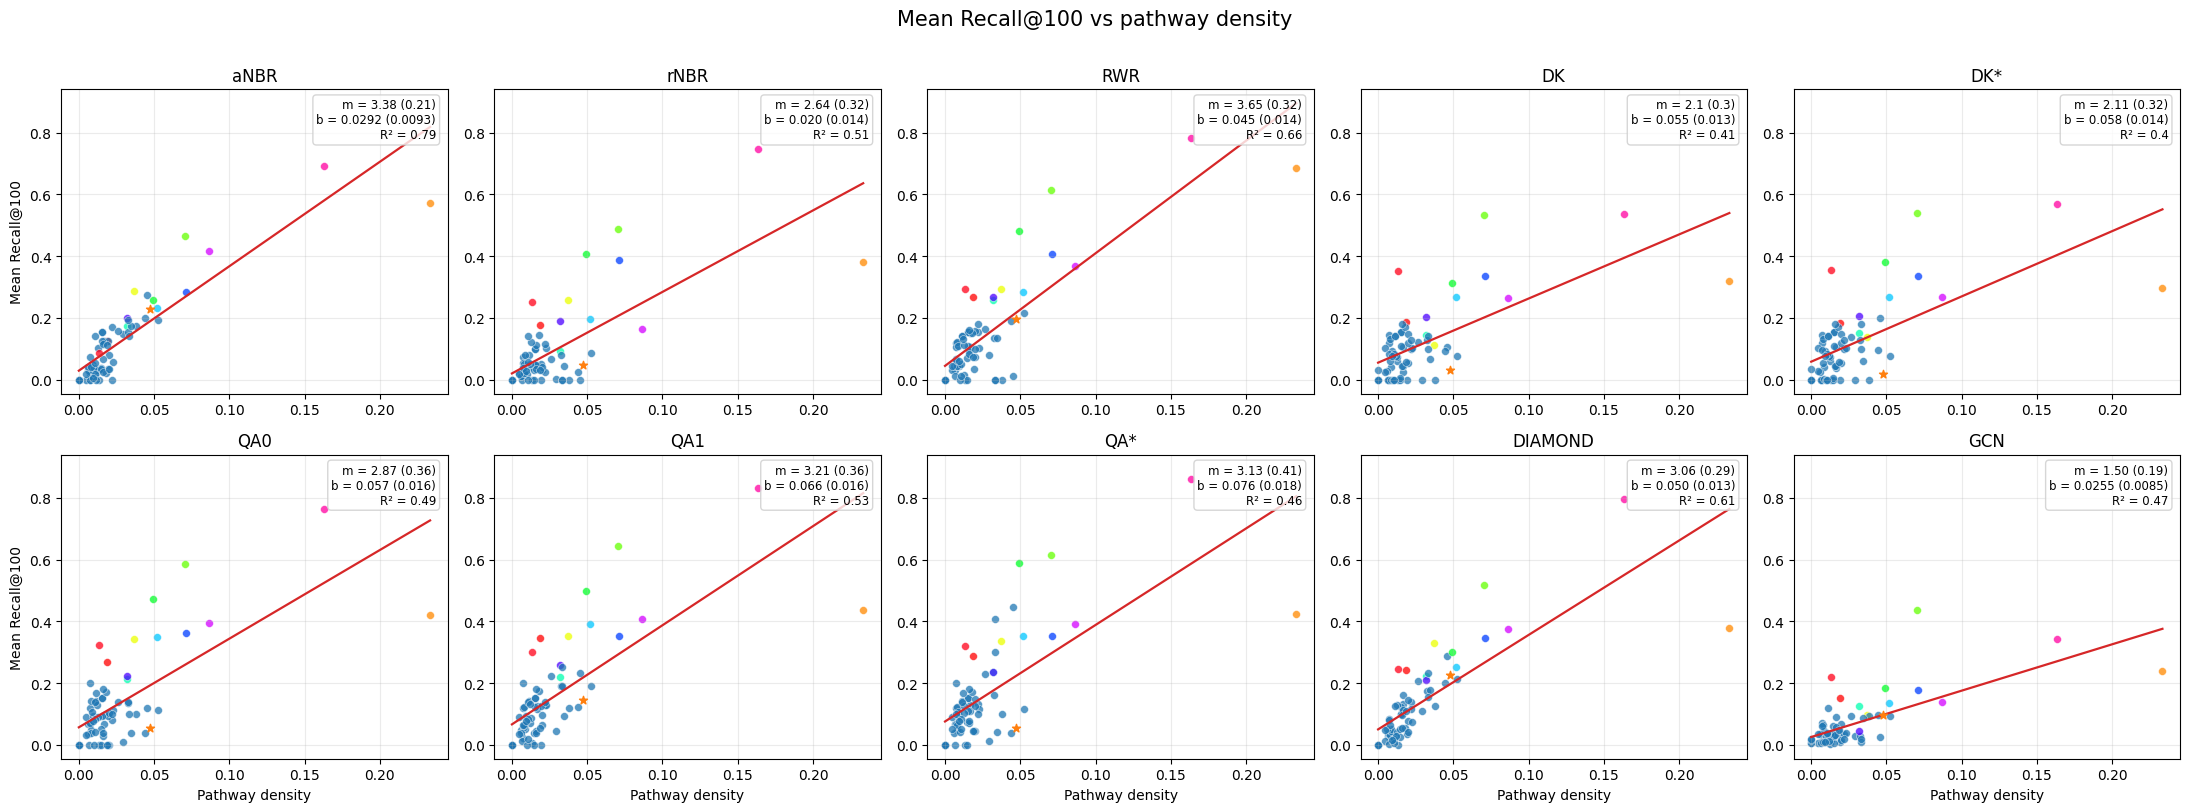

,disease,method,mean_pathway_metric,pathway_density,pathway_nodes,pathway_edges
0,adrenal gland diseases,DIAMOND,0.085,0.007353,17,1
1,adrenal gland diseases,DK,0.120,0.007353,17,1
2,adrenal gland diseases,DK*,0.120,0.007353,17,1
3,adrenal gland diseases,GCN,0.040,0.007353,17,1
4,adrenal gland diseases,QA*,0.120,0.007353,17,1


In [77]:
import math

import matplotlib.pyplot as plt
from scipy.stats import linregress

from bioGraph.data.loading import load_ppi_graph


metric_display_names = {"recall": "Recall", "average_precision": "AP"}
if pathway_metric not in metric_display_names:
    raise ValueError("pathway_metric must be 'recall' or 'average_precision'.")
pathway_metric_name = metric_display_names[pathway_metric]

# Ensure the selected metric/cutoff exists even with stale cached results.
# from an older execution of the notebook.
if pathway_metric_cutoff not in set(run_metrics["cutoff"].unique()):
    pathway_metric_rows = []
    for run in tqdm(runs, desc=f"{pathway_metric_name}@{pathway_metric_cutoff}"):
        for method_name in method_set:
            ranking = top_k_scores_to_ranking(
                run["scores"][method_name],
                nodelist,
                run["train_genes"],
                k=ranking_k,
            )
            metrics = compute_ranking_metrics(
                ranking, run["test_genes"], k=pathway_metric_cutoff
            )
            pathway_metric_rows.append({
                "disease": run["disease"],
                "seed": run["seed"],
                "method": method_name,
                "cutoff": pathway_metric_cutoff,
                **metrics,
            })
    run_metrics = pd.concat(
        [run_metrics, pd.DataFrame(pathway_metric_rows)], ignore_index=True
    )

mean_pathway_performance = (
    run_metrics.query("cutoff == @pathway_metric_cutoff")
    .groupby(["disease", "method"], as_index=False)[pathway_metric]
    .mean()
    .rename(columns={pathway_metric: "mean_pathway_metric"})
)

# Every split partitions the same known graph genes, so their union gives V_d.
disease_genes = {disease: set() for disease in disease_set}
for run in runs:
    disease_genes[run["disease"]].update(run["train_genes"])
    disease_genes[run["disease"]].update(run["test_genes"])

ppi_path = project_root / "data" / "raw" / "PPI202207.txt"
Ggen = load_ppi_graph(ppi_path)
density_rows = []
for disease_name, genes in disease_genes.items():
    pathway_nodes = set(genes) & set(Ggen)
    node_count = len(pathway_nodes)
    edge_count = Ggen.subgraph(pathway_nodes).number_of_edges()
    density = (
        2.0 * edge_count / (node_count * (node_count - 1))
        if node_count > 1 else 0.0
    )
    density_rows.append({
        "disease": disease_name,
        "pathway_density": density,
        "pathway_nodes": node_count,
        "pathway_edges": edge_count,
    })

pathway_density = pd.DataFrame(density_rows)
density_pathway_performance = mean_pathway_performance.merge(
    pathway_density, on="disease", validate="many_to_one"
)

n_columns = 5
n_rows = math.ceil(len(method_set) / n_columns)
fig, axes = plt.subplots(
    n_rows, n_columns, figsize=(4.4 * n_columns, 4.0 * n_rows),
    sharex=True, sharey=True, squeeze=False,
)
rwr_better_diseases = (
    density_pathway_performance.query(
        "method == 'RWR' and mean_pathway_metric > @color_threshold"
    )["disease"].tolist()
)
highlight_cmap = plt.get_cmap("hsv", max(len(rwr_better_diseases), 1))
highlight_colors = {
    disease: highlight_cmap(index)
    for index, disease in enumerate(rwr_better_diseases)
}

regression_rows = []
for plot_index, (axis, method_name) in enumerate(zip(axes.flat, method_set)):
    method_data = density_pathway_performance.query("method == @method_name")
    x_values = method_data["pathway_density"].to_numpy(dtype=float)
    y_values = method_data["mean_pathway_metric"].to_numpy(dtype=float)
    breast_mask = method_data["disease"].eq("breast neoplasms").to_numpy()
    for point_index, disease_name in enumerate(method_data["disease"]):
        if disease_name == "breast neoplasms":
            continue
        axis.scatter(
            x_values[point_index], y_values[point_index],
            color=highlight_colors.get(disease_name, "tab:blue"),
            s=32, alpha=0.75, edgecolor="white", linewidth=0.4,
        )
    axis.scatter(
        x_values[breast_mask], y_values[breast_mask],
        marker="*", color="tab:orange", zorder=5,
    )

    fit = linregress(x_values, y_values)
    x_fit = np.linspace(x_values.min(), x_values.max(), 200)
    axis.plot(
        x_fit, fit.intercept + fit.slope * x_fit,
        color="tab:red", linewidth=1.6,
    )
    fit_text = (
        f"m = {format_mean_std(fit.slope, fit.stderr)}\n"
        f"b = {format_mean_std(fit.intercept, fit.intercept_stderr)}\n"
        f"R² = {fit.rvalue ** 2:.2g}"
    )
    axis.text(
        0.97, 0.97, fit_text, transform=axis.transAxes,
        ha="right", va="top", fontsize=8.5,
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.8, "edgecolor": "0.8"},
    )
    regression_rows.append({
        "method": method_name,
        "slope": fit.slope,
        "slope_stderr": fit.stderr,
        "intercept": fit.intercept,
        "intercept_stderr": fit.intercept_stderr,
        "r_squared": fit.rvalue ** 2,
        "p_value": fit.pvalue,
    })

    axis.set_title(method_name)
    axis.grid(alpha=0.25)
    axis.tick_params(axis="both", labelbottom=True, labelleft=True)
    row_index, column_index = divmod(plot_index, n_columns)
    if row_index == n_rows - 1:
        axis.set_xlabel("Pathway density")
    if column_index == 0:
        axis.set_ylabel(f"Mean {pathway_metric_name}@{pathway_metric_cutoff}")

for axis in axes.flat[len(method_set):]:
    axis.set_visible(False)

pathway_density_regressions = pd.DataFrame(regression_rows)

fig.suptitle(
    f"Mean {pathway_metric_name}@{pathway_metric_cutoff} vs pathway density",
    fontsize=15, y=1.01,
)
fig.tight_layout()
plt.show()

display(density_pathway_performance.head())